In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Jalur ke folder dataset fitur tabel
dataset_dir = "../pistachio_raw/Pistachio_16_Features_Dataset"
print("Isi folder fitur:", os.listdir(dataset_dir))

Isi folder fitur: ['Pistachio_16_Features_Dataset.arff', 'Pistachio_16_Features_Dataset.xls', 'Pistachio_16_Features_Dataset.xlsx', 'Pistachio_16_Features_Dataset_Citation_Request.txt']


In [2]:
file_path = os.path.join(dataset_dir, "Pistachio_16_Features_Dataset.xlsx")
df = pd.read_excel(file_path)
print("--- Berhasil Membaca Dataset! Berikut 5 Data Teratas: ---")
display(df.head())

--- Berhasil Membaca Dataset! Berikut 5 Data Teratas: ---


,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,ROUNDNESS,COMPACTNESS,SHAPEFACTOR_1,SHAPEFACTOR_2,SHAPEFACTOR_3,SHAPEFACTOR_4,Class
0,63391,1568.405,390.3396,236.7461,0.7951,284.0984,0.8665,73160,0.6394,1.6488,0.3238,0.7278,0.0062,0.0037,0.5297,0.8734,Kirmizi_Pistachio
1,68358,1942.187,410.8594,234.7525,0.8207,295.0188,0.8765,77991,0.6772,1.7502,0.2277,0.7181,0.0060,0.0034,0.5156,0.9024,Kirmizi_Pistachio
2,73589,1246.538,452.3630,220.5547,0.8731,306.0987,0.9172,80234,0.7127,2.0510,0.5951,0.6767,0.0061,0.0030,0.4579,0.9391,Kirmizi_Pistachio
3,71106,1445.261,429.5291,216.0765,0.8643,300.8903,0.9589,74153,0.7028,1.9879,0.4278,0.7005,0.0060,0.0030,0.4907,0.9755,Kirmizi_Pistachio
4,80087,1251.524,469.3783,220.9344,0.8823,319.3273,0.9657,82929,0.7459,2.1245,0.6425,0.6803,0.0059,0.0028,0.4628,0.9833,Kirmizi_Pistachio


In [3]:
print("--- Informasi Struktur Dataset ---")
df.info()

print("\n--- Memeriksa Data yang Kosong (Missing Values) ---")
print(df.isnull().sum())

--- Informasi Struktur Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2148 entries, 0 to 2147
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AREA           2148 non-null   int64  
 1   PERIMETER      2148 non-null   float64
 2   MAJOR_AXIS     2148 non-null   float64
 3   MINOR_AXIS     2148 non-null   float64
 4   ECCENTRICITY   2148 non-null   float64
 5   EQDIASQ        2148 non-null   float64
 6   SOLIDITY       2148 non-null   float64
 7   CONVEX_AREA    2148 non-null   int64  
 8   EXTENT         2148 non-null   float64
 9   ASPECT_RATIO   2148 non-null   float64
 10  ROUNDNESS      2148 non-null   float64
 11  COMPACTNESS    2148 non-null   float64
 12  SHAPEFACTOR_1  2148 non-null   float64
 13  SHAPEFACTOR_2  2148 non-null   float64
 14  SHAPEFACTOR_3  2148 non-null   float64
 15  SHAPEFACTOR_4  2148 non-null   float64
 16  Class          2148 non-null   object 
dtypes: float64(14), i

--- Jumlah Data Per Jenis Kacang ---
Class
Kirmizi_Pistachio    1232
Siit_Pistachio        916
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_17976\726117839.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='Set2')


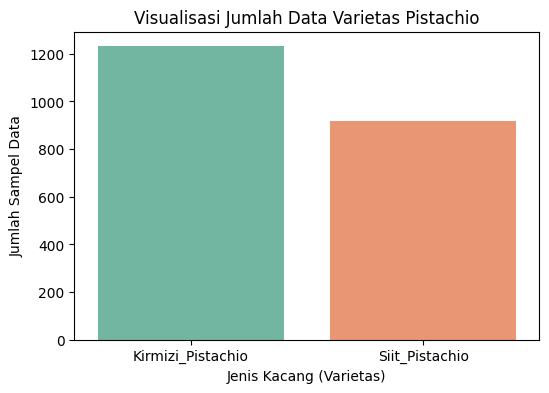

In [4]:
# Menghitung jumlah data per jenis kacang pada kolom 'Class'
jumlah_kelas = df['Class'].value_counts()
print("--- Jumlah Data Per Jenis Kacang ---")
print(jumlah_kelas)

# Membuat grafik batang warna-warni yang estetik
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df, palette='Set2')
plt.title('Visualisasi Jumlah Data Varietas Pistachio')
plt.xlabel('Jenis Kacang (Varietas)')
plt.ylabel('Jumlah Sampel Data')
plt.show()

In [5]:
# Menentukan X (Semua kolom kecuali kolom 'Class')
X = df.drop(columns=['Class'])

# Menentukan Y (Hanya kolom 'Class' sebagai target)
y = df['Class']

print("Fitur (X) dan Target (y) berhasil dipisahkan!")
print(f"Ukuran data fitur (X): {X.shape}")
print(f"Ukuran data target (y): {y.shape}")

Fitur (X) dan Target (y) berhasil dipisahkan!
Ukuran data fitur (X): (2148, 16)
Ukuran data target (y): (2148,)


In [6]:
from sklearn.preprocessing import LabelEncoder

# Inisialisasi LabelEncoder
le = LabelEncoder()

# Mengubah teks kelas menjadi angka (0 dan 1)
y_encoded = le.fit_transform(y)

print("--- Hasil Mengubah Target Menjadi Angka ---")
print("Teks Asli 5 data teratas:\n", y.head())
print("\nHasil Angka 5 data teratas:\n", y_encoded[:5])
print(f"\nKeterangan: Angka 0 = {le.classes_[0]}, Angka 1 = {le.classes_[1]}")

--- Hasil Mengubah Target Menjadi Angka ---
Teks Asli 5 data teratas:
 0    Kirmizi_Pistachio
1    Kirmizi_Pistachio
2    Kirmizi_Pistachio
3    Kirmizi_Pistachio
4    Kirmizi_Pistachio
Name: Class, dtype: object

Hasil Angka 5 data teratas:
 [0 0 0 0 0]

Keterangan: Angka 0 = Kirmizi_Pistachio, Angka 1 = Siit_Pistachio


In [7]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi 80% training dan 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print("--- Pembagian Dataset Berhasil! ---")
print(f"Jumlah data latihan (X_train): {X_train.shape[0]} baris")
print(f"Jumlah data pengujian (X_test): {X_test.shape[0]} baris")

--- Pembagian Dataset Berhasil! ---
Jumlah data latihan (X_train): 1718 baris
Jumlah data pengujian (X_test): 430 baris
